<h1>Medical Image Segmentation AI Model</h1>

This code uses the dataset from Cybele

In developing the model I have used the MONAI Documentation continuously: https://docs.monai.io/en/stable/networks.html

Additionally I have used inspiration from MONAI's Tutorial Repository: https://github.com/Project-MONAI/tutorials/blob/main/3d_segmentation/unet_segmentation_3d_ignite.ipynb

I have also used ChatGPT for help with errors and some debugging

In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
import torch
import matplotlib.pyplot as plt
from monai.data import Dataset, DataLoader
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd, Spacingd, SpatialPadd,
    RandCropByPosNegLabeld, RandRotate90d, RandFlipd, RandGaussianNoised, ToTensord, EnsureTyped, 
)
from monai.networks.nets import UNet
from monai.losses import DiceLoss, DiceFocalLoss
from monai.metrics import DiceMetric
from monai.optimizers import Novograd
from monai.inferers import sliding_window_inference
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split

<h3>Loading data</h3>

In [ ]:
# Use of ChatGPT for help with loading data
base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/train"

case_dirs = sorted(glob.glob(os.path.join(base_dir, "*")))
data = []

for case_dir in case_dirs:
    case_id = os.path.basename(case_dir) 
    image_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_T2.nii.gz")
    label_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_mask.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        data.append({"image": image_path, "label": label_path})
    else:
        print(f"Missing data for case {case_id}, skipping.")

print(f"Found {len(data)} samples.")

# Split the data into training and validation sets
train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)  # 80% train, 20% validation

Found 130 samples.


<h3>Data Transformations</h3>

In [ ]:
# Transforms for data preprocessing
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(0.6,0.6,1.8), mode=("bilinear", "nearest")), # Voxel spacing from EDA
    NormalizeIntensityd(keys=["image"]),
    SpatialPadd(keys=["image", "label"], spatial_size=[256, 256, 64]), # Ensure at least as big sa crop
    RandCropByPosNegLabeld( # Crop instead of resize for medical consistency
        keys=["image", "label"],
        label_key="label",
        image_key="image",
        spatial_size=(256, 256, 64),
        pos=2, # force some positive crops
        neg=1, # allow negative crops
        num_samples=3, # number of patches per volume
    ),
    # Data augmentation (free method of enhancing generalization)
    RandRotate90d(keys=["image", "label"], prob=0.3),
    RandFlipd(keys=["image", "label"], prob=0.3),
    RandGaussianNoised(keys=["image"], prob=0.1),
    # Final transformations
    ToTensord(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
])
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(0.6,0.6,1.8), mode=("bilinear", "nearest")), # Same spacing as in training
    NormalizeIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
])

# Dataset and DataLoader
train_dataset = Dataset(data=train_data, transform=train_transforms) # Loading and transforming data
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=8, persistent_workers=True, pin_memory=True) # Loads 4 batches in parallel

val_dataset = Dataset(data=val_data, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)  #batch size 1 allows different sized images in val

<h3>Building the Model</h3>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)

# Define the UNet model
model = UNet(
    spatial_dims=3, # 3D model (volumetric MRI data)
    in_channels=1, # Single-channel input (T2 MRI image -> greyscale)
    out_channels=1, # Single output channel (binary tumor mask)
    channels=(32, 64, 128, 256, 512), # 5 levels deep
    strides=(2, 2, 2, 2), # (256,256,64) -> (128,128,32) -> (64,64,16) -> (32,32,8) -> (16,16,4) -> and up again 
    dropout=0.3, # Dropout for better generalization
).to(device)

# Loss function
loss_function = DiceFocalLoss(include_background=True, sigmoid=True) # Better as tumors are small (from EDA), focus on hard examples. 

# Optimizer and scheduler
# Change to AdamW to try lr scheduler (not regular Adam as we want L2 regularization)
optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)  # wd to 1e-5 (enough to not overfit) isntead of 1e-2 as we have a small dataset and small tumors
scheduler = StepLR(optimizer, step_size=10, gamma=0.5) # lr multiplied by 0.5 every 10 epochs

# Dice metric for evaluation
train_dice_metric = DiceMetric(include_background=True, reduction="mean")
val_dice_metric = DiceMetric(include_background=True, reduction="mean")

# Automatic Mixed Precicion (AMP) -> reduced memory and training time
scaler = GradScaler()


Using device: cuda


<h3>Training the Model</h3>

In [ ]:
num_epochs = 50
best_val_dice = 0.0
train_losses, train_dices, val_dices = [], [], []

# Training loop
for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_loss = 0.0
    epoch_train_dice = 0.0
    train_dice_metric.reset()

    for batch_data in train_loader:
        images = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)
        labels = (labels > 0).float() # Binary

        optimizer.zero_grad() # clear old gradients
        with autocast(device_type="cuda"): # Forward pass in mixed precision
            outputs = model(images)
            loss = loss_function(outputs, labels)

        scaler.scale(loss).backward() # Compute gradients with b-pass with scaled loss
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Limit exploding gradients
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        outputs = torch.sigmoid(outputs)
        preds = (outputs > 0.5).float() # Binary
        train_dice_metric(preds, labels)

    epoch_loss /= len(train_loader)
    epoch_train_dice = train_dice_metric.aggregate().item()
    scheduler.step()

    # Validation phase
    model.eval()
    epoch_val_dice = 0.0
    val_dice_metric.reset()
    with torch.no_grad(): # disable gradient computation
        for batch_data in val_loader:
            images = batch_data["image"].to(device)
            labels = batch_data["label"].to(device)
            with autocast(device_type="cuda"):
                outputs = sliding_window_inference( # to handle 3d volume and have correct output shape
                    images,
                    roi_size=[192, 192, 64],
                    sw_batch_size=1,
                    predictor=model,
                    overlap=0.25 # for smoother output
                )
            outputs = torch.sigmoid(outputs)
            preds = (outputs > 0.5).float()
            val_dice_metric(preds, labels)

    epoch_val_dice = val_dice_metric.aggregate().item()

    if epoch_val_dice > best_val_dice:
        best_val_dice = epoch_val_dice
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved new best model with Val Dice:", best_val_dice)

    train_losses.append(epoch_loss)
    train_dices.append(epoch_train_dice)
    val_dices.append(epoch_val_dice)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Training Loss: {epoch_loss:.4f}, Training Dice: {epoch_train_dice:.4f}")
    print(f"  Validation Dice: {epoch_val_dice:.4f}")

Saved new best model with Val Dice: 0.002680962672457099
Epoch 1/50
  Training Loss: 1.4505, Training Dice: 0.0159
  Validation Dice: 0.0027
Saved new best model with Val Dice: 0.0038772623520344496
Epoch 2/50
  Training Loss: 1.2527, Training Dice: 0.0150
  Validation Dice: 0.0039
Saved new best model with Val Dice: 0.003899945644661784
Epoch 3/50
  Training Loss: 1.1529, Training Dice: 0.0168
  Validation Dice: 0.0039
Epoch 4/50
  Training Loss: 1.0952, Training Dice: 0.0203
  Validation Dice: 0.0018
Epoch 5/50
  Training Loss: 1.0603, Training Dice: 0.0262
  Validation Dice: 0.0035
Epoch 6/50
  Training Loss: 1.0385, Training Dice: 0.0309
  Validation Dice: 0.0028
Epoch 7/50
  Training Loss: 1.0243, Training Dice: 0.0413
  Validation Dice: 0.0011
Epoch 8/50
  Training Loss: 1.0142, Training Dice: 0.0481
  Validation Dice: 0.0033
Saved new best model with Val Dice: 0.04727275297045708
Epoch 9/50
  Training Loss: 1.0052, Training Dice: 0.0670
  Validation Dice: 0.0473
Saved new best m

<h3>Visualization of Training</h3>

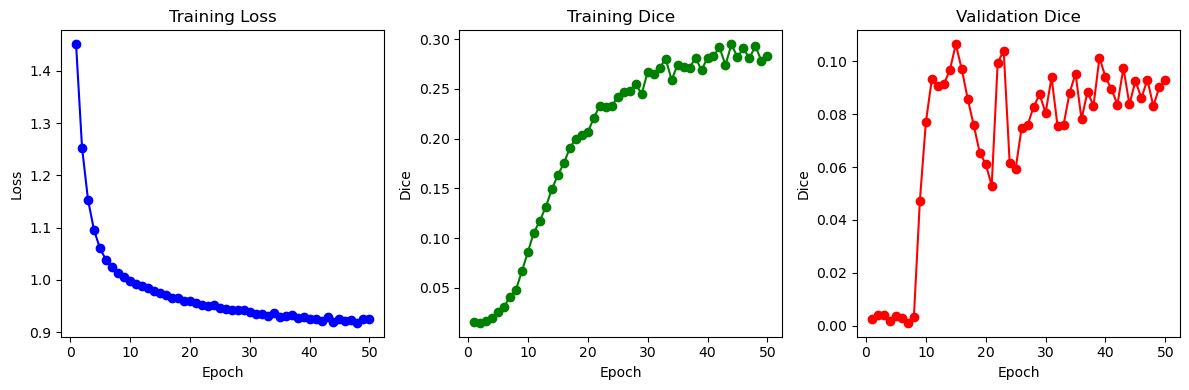

In [ ]:
# Use of ChatGPT for help with plotting
epochs = range(1, num_epochs+1)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(epochs, train_losses, 'b-o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,3,2)
plt.plot(epochs, train_dices, 'g-o')
plt.title('Training Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice')

plt.subplot(1,3,3)
plt.plot(epochs, val_dices, 'r-o')
plt.title('Validation Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice')

plt.tight_layout()
plt.show()

<h3>Evaluation</h3>

In [ ]:
test_base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/test" 

test_case_dirs = sorted(glob.glob(os.path.join(test_base_dir, "*")))
test_data = []

for case_dir in test_case_dirs:
    case_id = os.path.basename(case_dir)
    image_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_T2.nii.gz")
    label_path = os.path.join(case_dir, "preRT", f"{case_id}_preRT_mask.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        test_data.append({"image": image_path, "label": label_path})
    else:
        print(f"Missing data for case {case_id}, skipping.")

print(f"Found {len(test_data)} test samples.")


Found 20 test samples.


In [ ]:
test_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(0.6,0.6,1.8), mode=("bilinear", "nearest")), # Same as in training
    NormalizeIntensityd(keys=["image"]),
    ToTensord(keys=["image", "label"], track_meta=True),
    EnsureTyped(keys=["image", "label"], track_meta=True),
])

# Create the test dataset and dataloader
test_dataset = Dataset(data=test_data, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False) # No shuffling for evaluation

In [ ]:
# Load the model and set it to evaluation mode
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 128, 256, 512), 
    strides=(2, 2, 2, 2),
    dropout=0.3,
).to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# Initialize same lossfunction and metric for dice score
loss_function = DiceFocalLoss(include_background=True, sigmoid=True)
test_dice_metric = DiceMetric(include_background=True, reduction="mean")

test_loss_total = 0.0
test_dice_metric.reset()

with torch.no_grad():
    for i, test_batch in enumerate(test_loader):
        images = test_batch["image"].to(device)
        labels = test_batch["label"].to(device) 

        affine = images.meta["affine"].cpu().numpy()
        if affine.shape == (1, 4, 4):
            affine = affine[0]

        with autocast(device_type="cuda"):
            outputs = sliding_window_inference(
                images,
                roi_size=(256, 256, 64),
                sw_batch_size=1,
                predictor=model,
                overlap=0.25
            )

        loss = loss_function(outputs, labels)
        test_loss_total += loss.item()

        outputs = torch.sigmoid(outputs)
        preds = (outputs > 0.5).float() # binary
        test_dice_metric(preds, labels)

        # Save predictions
        save_dir = os.path.join(os.getcwd(), "test_predictions_v5")
        os.makedirs(save_dir, exist_ok=True)
        pred_np = preds.squeeze().cpu().numpy().astype(np.uint8)
        case_id = os.path.basename(test_case_dirs[i])
        save_path = os.path.join(save_dir, f"{case_id}_prediction.nii.gz")
        nib.save(nib.Nifti1Image(pred_np, affine), save_path)

# Average over all test samples
avg_test_loss = test_loss_total / len(test_loader)
avg_test_dice = test_dice_metric.aggregate().item()

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Dice: {avg_test_dice:.4f}")


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Test Loss: 0.9788
Test Dice: 0.1568


<h3>Visualization of Test Results</h3>

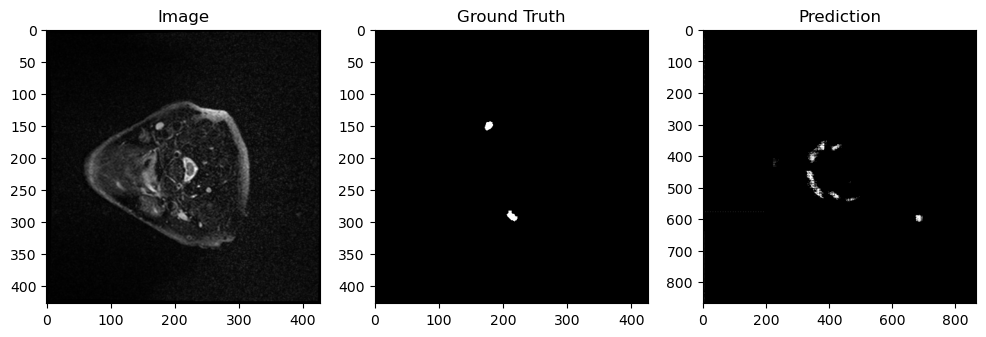

In [ ]:
# Use of chatGPT for help with visualization
batch_data = next(iter(test_loader))
image = batch_data["image"][0].cpu().numpy()
label = batch_data["label"][0].cpu().numpy()
output = outputs[0].cpu().numpy()

# Plot of the original image, ground truth, and prediction
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image[0, :, :, 32], cmap="gray")
plt.title("Image")

plt.subplot(1, 3, 2)
plt.imshow(label[0, :, :, 32], cmap="gray")
plt.title("Ground Truth")

plt.subplot(1, 3, 3)
plt.imshow(output[0, :, :, 32] > 0.5, cmap="gray")  # Threshold for the prediction
plt.title("Prediction")

plt.show()
